# **Logistic Regression for Imbalanced dataset**

In [1]:
# Generate and plot a synthetic imbalanced classification dataset
from collections import Counter
from sklearn.datasets import make_classification

In [2]:
## imbalanced dataset
X,y = make_classification(n_samples = 10000, n_features=2, n_clusters_per_class=1, n_redundant=0, weights=[0.99], random_state=10)

In [3]:
X

array([[ 1.87991016, -1.4850347 ],
       [ 0.37708311, -2.23858488],
       [ 1.35431163, -2.66463822],
       ...,
       [ 0.99509904, -0.54192355],
       [ 1.75859359, -1.54961188],
       [ 0.79770543, -1.99467372]])

In [4]:
y

array([0, 0, 0, ..., 0, 0, 0])

In [6]:
Counter(y)

Counter({np.int64(0): 9846, np.int64(1): 154})

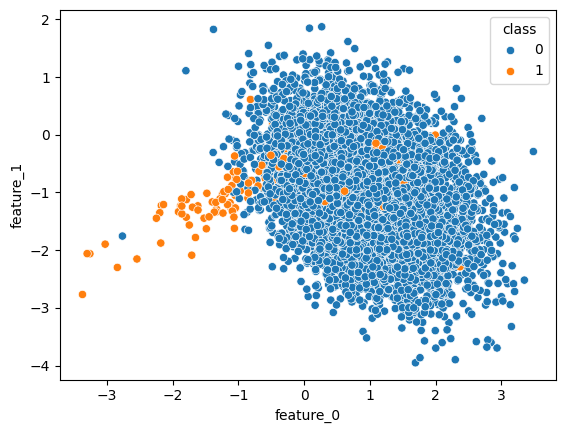

In [15]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df_plot = pd.DataFrame(X, columns=['feature_0', 'feature_1'])
df_plot['class'] = y
sns.scatterplot(x='feature_0', y='feature_1', hue='class', data=df_plot)
plt.show()

In [17]:
pd.DataFrame(X)[0]

,0
0,1.879910
1,0.377083
2,1.354312
3,-0.509843
4,0.863561
...,...
9995,1.066698
9996,1.058723
9997,0.995099
9998,1.758594


In [19]:
pd.DataFrame(X)[1]

,1
0,-1.485035
1,-2.238585
2,-2.664638
3,-1.502950
4,-1.906364
...,...
9995,-0.548159
9996,-0.933768
9997,-0.541924
9998,-1.549612


<Axes: xlabel='0', ylabel='1'>

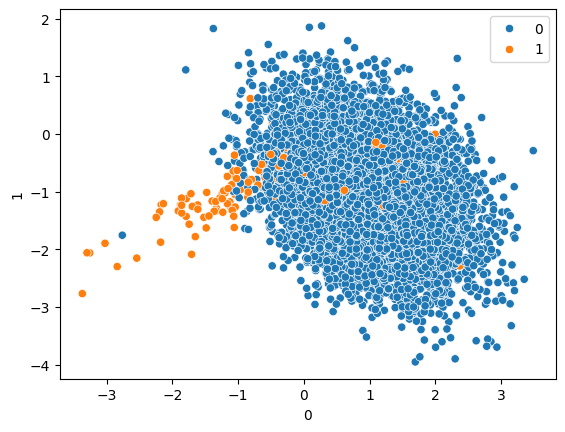

In [20]:
import pandas as pd
import seaborn as sns
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [35]:
# Split the dataset into train and test sets
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.25, random_state=42)

In [36]:
class_weight = [{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [37]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [38]:
#Hyperparameter tuning
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()
penalty = ['l1', 'l2', 'elasticnet']
c_values = [100, 10, 1.0, 0.1, 0.01]
solver = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
class_weight = [{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [39]:
params = dict(penalty=penalty, C=c_values, solver=solver, class_weight=class_weight)

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
cv = StratifiedKFold()
grid = GridSearchCV(estimator=logistic, param_grid=params, cv=cv, scoring='accuracy')

In [42]:
grid.fit(train_X, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [43]:
grid.best_score_

np.float64(0.9882666666666667)

In [45]:
grid.best_params_

{'C': 100,
 'class_weight': {0: 50, 1: 100},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [46]:
y_pred = grid.predict(test_X)

In [48]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(accuracy_score(test_y, y_pred))
print('---------------------------------')
print(classification_report(test_y, y_pred))
print('----------------------------------')
print(confusion_matrix(test_y, y_pred))

0.9896
---------------------------------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2465
           1       1.00      0.26      0.41        35

    accuracy                           0.99      2500
   macro avg       0.99      0.63      0.70      2500
weighted avg       0.99      0.99      0.99      2500

----------------------------------
[[2465    0]
 [  26    9]]
